In [1]:
# plotting the results of the benchmark 
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
from matplotlib.ticker import LogLocator

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]


## Dataframe generation 

This extracts the runtime and resource usage for the 30 replicate runs and constructs a data frame saved to csv 

In [7]:
# initiating empty lists to store the values
# --- matlab ---
matlab_intensity_realtime_values = []
matlab_intensity_peak_rss_values = []
matlab_intensity_rchar_values = []
matlab_intensity_wchar_values = []
matlab_intensity_read_bytes_values = []
matlab_intensity_write_bytes_values = []
matlab_intensity_pmem_values = []
matlab_intensity_pcpu_values = []


matlab_alignment_realtime_values = []
matlab_alignment_peak_rss_values = []
matlab_alignment_rchar_values = []
matlab_alignment_wchar_values = []
matlab_alignment_read_bytes_values = []
matlab_alignment_write_bytes_values = []
matlab_alignment_pmem_values = []
matlab_alignment_pcpu_values = []

matlab_stitching_realtime_values = []
matlab_stitching_peak_rss_values = []
matlab_stitching_rchar_values = []
matlab_stitching_wchar_values = []
matlab_stitching_read_bytes_values = []
matlab_stitching_write_bytes_values = []
matlab_stitching_pmem_values = []
matlab_stitching_pcpu_values = []

matlab_count_realtime_values = []
matlab_count_peak_rss_values = []
matlab_count_rchar_values = []
matlab_count_wchar_values = []
matlab_count_read_bytes_values = []
matlab_count_write_bytes_values = []
matlab_count_pmem_values = []
matlab_count_pcpu_values = []

# --- nextflow ---
nextflow_intensity_realtime_values = []
nextflow_intensity_peak_rss_values = []
nextflow_intensity_rchar_values = []
nextflow_intensity_wchar_values = []
nextflow_intensity_read_bytes_values = []
nextflow_intensity_write_bytes_values = []
nextflow_intensity_pmem_values = []
nextflow_intensity_pcpu_values = []


nextflow_alignment_realtime_values = []
nextflow_alignment_peak_rss_values = []
nextflow_alignment_rchar_values = []
nextflow_alignment_wchar_values = []
nextflow_alignment_read_bytes_values = []
nextflow_alignment_write_bytes_values = []
nextflow_alignment_pmem_values = []
nextflow_alignment_pcpu_values = []


nextflow_stitching_realtime_values = []
nextflow_stitching_peak_rss_values = []
nextflow_stitching_rchar_values = []
nextflow_stitching_wchar_values = []
nextflow_stitching_read_bytes_values = []
nextflow_stitching_write_bytes_values = []
nextflow_stitching_pmem_values = []
nextflow_stitching_pcpu_values = []

nextflow_count_realtime_values = []
nextflow_count_peak_rss_values = []
nextflow_count_rchar_values = []
nextflow_count_wchar_values = []
nextflow_count_read_bytes_values = []
nextflow_count_write_bytes_values = []
nextflow_count_pmem_values = []
nextflow_count_pcpu_values = []


In [8]:
# aggregate data from matlab/replicate_[index]/process_intensity/ get the matlab_trace.log file and extract the realtime value.

#iterate over the list of strings for the index since they are 0 padded in the folder names
for i in replicate_indices:
    with open(f'matlab/replicate_{i}/process_intensity/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_intensity_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_intensity_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_intensity_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_intensity_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_intensity_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_intensity_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_intensity_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_intensity_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_align/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_alignment_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_alignment_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_alignment_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_alignment_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_alignment_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_alignment_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_alignment_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_alignment_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_stitch/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_stitching_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_stitching_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_stitching_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_stitching_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_stitching_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_stitching_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_stitching_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_stitching_pcpu_values.append(cpu_value)
    with open(f'matlab/replicate_{i}/process_count/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_count_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_count_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_count_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_count_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_count_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_count_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_count_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_count_pcpu_values.append(cpu_value)

In [9]:
# from the value arrays create a pandas datafram with the following columns: 
# process; realtime; peak_rss; software
# and the values in the process column should be 'intensity', 'alignment', 'stitching', 'count'
# the software column should be 'matlab' for the matlab values and 'nextflow' for the nextflow values

matlab_df = pd.DataFrame({
    'process': ['intensity'] * len(matlab_intensity_realtime_values) +
               ['alignment'] * len(matlab_alignment_realtime_values) +
               ['stitching'] * len(matlab_stitching_realtime_values) +
               ['count'] * len(matlab_count_realtime_values),
    'realtime': matlab_intensity_realtime_values +
                matlab_alignment_realtime_values +
                matlab_stitching_realtime_values +
                matlab_count_realtime_values,
    'peak_rss': matlab_intensity_peak_rss_values +
                matlab_alignment_peak_rss_values +
                matlab_stitching_peak_rss_values +
                matlab_count_peak_rss_values,
    'rchar': matlab_intensity_rchar_values +
             matlab_alignment_rchar_values +
             matlab_stitching_rchar_values +
             matlab_count_rchar_values,
    'wchar': matlab_intensity_wchar_values +
             matlab_alignment_wchar_values +
             matlab_stitching_wchar_values +
             matlab_count_wchar_values,
    'read_bytes': matlab_intensity_read_bytes_values +
                  matlab_alignment_read_bytes_values +
                  matlab_stitching_read_bytes_values +
                  matlab_count_read_bytes_values,
    'write_bytes': matlab_intensity_write_bytes_values +
                   matlab_alignment_write_bytes_values +
                   matlab_stitching_write_bytes_values +
                   matlab_count_write_bytes_values,
    'pmem': matlab_intensity_pmem_values +
            matlab_alignment_pmem_values +
            matlab_stitching_pmem_values +
            matlab_count_pmem_values,
    'pcpu': matlab_intensity_pcpu_values +
            matlab_alignment_pcpu_values +
            matlab_stitching_pcpu_values +
            matlab_count_pcpu_values, 
    'software': ['matlab'] * (len(matlab_intensity_realtime_values) +
                             len(matlab_alignment_realtime_values) +
                             len(matlab_stitching_realtime_values) +
                             len(matlab_count_realtime_values))
})



In [10]:
matlab_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software
0,intensity,33871.0,1616856.0,98550442.0,183114877.0,4096.0,183414784.0,24.0,1781.0,matlab
1,intensity,33357.0,1596580.0,98550430.0,183114877.0,532480.0,183418880.0,24.0,1836.0,matlab
2,intensity,34107.0,1663488.0,98551219.0,183114878.0,8192.0,183414784.0,24.0,1788.0,matlab
3,intensity,32765.0,1615904.0,98042676.0,183114881.0,8192.0,183410688.0,24.0,1840.0,matlab
4,intensity,34082.0,1598552.0,98550455.0,183114881.0,8192.0,183414784.0,24.0,1769.0,matlab
...,...,...,...,...,...,...,...,...,...,...
115,count,149343.0,10866372.0,65443396.0,2190444.0,0.0,2600960.0,165.0,44.0,matlab
116,count,149634.0,10871796.0,67532283.0,2190442.0,0.0,2596864.0,166.0,45.0,matlab
117,count,149669.0,10861532.0,65445296.0,2190440.0,0.0,2588672.0,166.0,45.0,matlab
118,count,146100.0,10839892.0,65436556.0,2190444.0,0.0,2580480.0,165.0,46.0,matlab


In [13]:
# get the data from the work dir -- correct values --- 
# create df with columns: process; hash/id
nextflow_id_df = pd.DataFrame(columns=['replicate','process', 'hash/id'])
# fill the df with the values from the files by iterating over the replicates and processes
for i in replicate_indices:
    file_pattern = f'nextflow/replicate_{i}/pipeline_info/execution_trace_*.txt'
    file_list = glob.glob(file_pattern)
    if file_list:
        df = pd.read_csv(file_list[0], sep='\t')
        # Create rows to add
        rows_to_add = [
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)']['hash'].values[0]}
        ]
        
        # Use pd.concat to add rows
        nextflow_id_df = pd.concat([nextflow_id_df, pd.DataFrame(rows_to_add)], ignore_index=True)

In [14]:
nextflow_id_df

# adding two new empty columns to the dataframe 
nextflow_id_df['realtime'] = np.nan
nextflow_id_df['peak_rss'] = np.nan
nextflow_id_df['rchar'] = np.nan
nextflow_id_df['wchar'] = np.nan
nextflow_id_df['read_bytes'] = np.nan
nextflow_id_df['write_bytes'] = np.nan
nextflow_id_df['pmem'] = np.nan
nextflow_id_df['pcpu'] = np.nan


In [15]:
# now iterating over the  rows in the dataframe, getting into the work dir and from the hash in the dataframe into the right sub dir to finde there the trace file and add real time and peak rss to the dataframe for the specific hash 
for index, row in nextflow_id_df.iterrows():
    replicate = row['replicate']
    process = row['process']
    hash_id = row['hash/id']
    
    # Construct the path to the trace file with glob pattern to find the trace file in the right subdir
    trace_file_pattern = f'nextflow/replicate_{replicate}/work/{hash_id}*/.command.trace'
    trace_file_path = glob.glob(trace_file_pattern)
    if trace_file_path:
        with open(trace_file_path[0], 'r') as f:
            for line in f:
                if 'realtime' in line:
                    realtime_value = float(line.split('realtime=')[1].strip())
                    # get the row with the current replicate and add the realtime value to the realtime column
                    nextflow_id_df.at[index, 'realtime'] = realtime_value
                if 'peak_rss' in line:
                    peak_rss_value = float(line.split('peak_rss=')[1].strip())
                    nextflow_id_df.at[index, 'peak_rss'] = peak_rss_value
                if 'rchar' in line:
                    rchar_value = float(line.split('rchar=')[1].strip())
                    nextflow_id_df.at[index, 'rchar'] = rchar_value
                if 'wchar' in line:
                    wchar_value = float(line.split('wchar=')[1].strip())
                    nextflow_id_df.at[index, 'wchar'] = wchar_value
                if 'read_bytes' in line:
                    read_bytes_value = float(line.split('read_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'read_bytes'] = read_bytes_value
                if 'write_bytes' in line:
                    write_bytes_value = float(line.split('write_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'write_bytes'] = write_bytes_value
                if '%mem' in line:
                    mem_value = float(line.split('%mem=')[1].strip())
                    nextflow_id_df.at[index, 'pmem'] = mem_value
                if '%cpu' in line:
                    cpu_value = float(line.split('%cpu=')[1].strip())
                    nextflow_id_df.at[index, 'pcpu'] = cpu_value


In [16]:
nextflow_id_df

,replicate,process,hash/id,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu
0,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,d4/b78637,34914.0,1494476.0,265995630.0,3.121421e+08,8085504.0,3.174359e+08,23.0,1786.0
1,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,66/a2ebe6,91367.0,1549044.0,357167486.0,1.949282e+08,94208.0,2.002412e+08,22.0,5756.0
2,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,de/b125c7,162310.0,1868976.0,537681869.0,2.252291e+09,184320.0,2.257904e+09,24.0,1395.0
3,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),de/530721,970581.0,14317624.0,441947545.0,1.869282e+06,53248.0,1.871872e+06,218.0,1014.0
4,02,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,c9/a63102,34971.0,1496744.0,266489989.0,3.121421e+08,12148736.0,3.174318e+08,23.0,1777.0
...,...,...,...,...,...,...,...,...,...,...,...
115,29,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),09/2cac63,976950.0,14429440.0,441947438.0,1.869282e+06,0.0,1.871872e+06,219.0,1014.0
116,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,5a/09cc31,34816.0,1454536.0,265998622.0,3.121421e+08,9113600.0,3.174359e+08,22.0,1801.0
117,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,56/5951e0,89233.0,1547740.0,356668699.0,1.949282e+08,73728.0,2.002412e+08,22.0,5783.0
118,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,66/d25ea8,160389.0,1920260.0,541366348.0,2.252291e+09,192512.0,2.257904e+09,26.0,1401.0


In [17]:
# replace the process names to be matched with the matlab df process names
nextflow_id_df['process'] = nextflow_id_df['process'].replace({
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)': 'intensity',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)': 'alignment',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)': 'stitching',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)': 'count'
})  



In [18]:
# combine both dataframe and write them to csv. 
# first drop hash column from nextflow_id_df
nextflow_id_df = nextflow_id_df.drop(columns=['hash/id'])
# add software column to nextflow_id_df with value 'nextflow'
nextflow_id_df['software'] = 'nextflow'
# concatenate the two dataframes
combined_df = pd.concat([matlab_df, nextflow_id_df], ignore_index=True)
# write the combined dataframe to csv
combined_df.to_csv('benchmark_results.csv', index=False)    


In [60]:
combined_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NuMorph,NaN


## Plotting results 


In [2]:

#read in the saved combinde dataframe from csv . 
raw_benchmark_df = pd.read_csv('benchmark_results.csv')
raw_benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,33871.0,1616856.0,98550442.0,1.831149e+08,4096.0,1.834148e+08,24.0,1781.0,matlab,NaN
1,intensity,33357.0,1596580.0,98550430.0,1.831149e+08,532480.0,1.834189e+08,24.0,1836.0,matlab,NaN
2,intensity,34107.0,1663488.0,98551219.0,1.831149e+08,8192.0,1.834148e+08,24.0,1788.0,matlab,NaN
3,intensity,32765.0,1615904.0,98042676.0,1.831149e+08,8192.0,1.834107e+08,24.0,1840.0,matlab,NaN
4,intensity,34082.0,1598552.0,98550455.0,1.831149e+08,8192.0,1.834148e+08,24.0,1769.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,976950.0,14429440.0,441947438.0,1.869282e+06,0.0,1.871872e+06,219.0,1014.0,nextflow,29.0
236,intensity,34816.0,1454536.0,265998622.0,3.121421e+08,9113600.0,3.174359e+08,22.0,1801.0,nextflow,30.0
237,alignment,89233.0,1547740.0,356668699.0,1.949282e+08,73728.0,2.002412e+08,22.0,5783.0,nextflow,30.0
238,stitching,160389.0,1920260.0,541366348.0,2.252291e+09,192512.0,2.257904e+09,26.0,1401.0,nextflow,30.0


In [3]:
# convert realtime from miliseconds to seconds and peak_rss from bytes to gb 
benchmark_df = raw_benchmark_df.copy()
benchmark_df['realtime'] = benchmark_df['realtime'] / 60000
benchmark_df['peak_rss'] = benchmark_df['peak_rss'] / (1024 * 1024) 
benchmark_df['read_bytes'] = benchmark_df['read_bytes'] / (1024 )
benchmark_df['write_bytes'] = benchmark_df['write_bytes'] / (1024 )
benchmark_df['pcpu'] = benchmark_df['pcpu'] / 10
benchmark_df['pmem'] = benchmark_df['pmem'] / 10
benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,0.564517,1.541954,98550442.0,1.831149e+08,4.0,179116.0,2.4,178.1,matlab,NaN
1,intensity,0.555950,1.522617,98550430.0,1.831149e+08,520.0,179120.0,2.4,183.6,matlab,NaN
2,intensity,0.568450,1.586426,98551219.0,1.831149e+08,8.0,179116.0,2.4,178.8,matlab,NaN
3,intensity,0.546083,1.541046,98042676.0,1.831149e+08,8.0,179112.0,2.4,184.0,matlab,NaN
4,intensity,0.568033,1.524498,98550455.0,1.831149e+08,8.0,179116.0,2.4,176.9,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,16.282500,13.760986,441947438.0,1.869282e+06,0.0,1828.0,21.9,101.4,nextflow,29.0
236,intensity,0.580267,1.387154,265998622.0,3.121421e+08,8900.0,309996.0,2.2,180.1,nextflow,30.0
237,alignment,1.487217,1.476040,356668699.0,1.949282e+08,72.0,195548.0,2.2,578.3,nextflow,30.0
238,stitching,2.673150,1.831303,541366348.0,2.252291e+09,188.0,2204984.0,2.6,140.1,nextflow,30.0


In [ ]:
# rename software
#summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df


,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,software,replicate
0,intensity,0.564517,1.541954,98550442.0,1.831149e+08,4.0,179116.0,2.4,178.1,NuMorph,NaN
1,intensity,0.555950,1.522617,98550430.0,1.831149e+08,520.0,179120.0,2.4,183.6,NuMorph,NaN
2,intensity,0.568450,1.586426,98551219.0,1.831149e+08,8.0,179116.0,2.4,178.8,NuMorph,NaN
3,intensity,0.546083,1.541046,98042676.0,1.831149e+08,8.0,179112.0,2.4,184.0,NuMorph,NaN
4,intensity,0.568033,1.524498,98550455.0,1.831149e+08,8.0,179116.0,2.4,176.9,NuMorph,NaN
...,...,...,...,...,...,...,...,...,...,...,...
235,count,16.282500,13.760986,441947438.0,1.869282e+06,0.0,1828.0,21.9,101.4,nf-core/lsmquant,29.0
236,intensity,0.580267,1.387154,265998622.0,3.121421e+08,8900.0,309996.0,2.2,180.1,nf-core/lsmquant,30.0
237,alignment,1.487217,1.476040,356668699.0,1.949282e+08,72.0,195548.0,2.2,578.3,nf-core/lsmquant,30.0
238,stitching,2.673150,1.831303,541366348.0,2.252291e+09,188.0,2204984.0,2.6,140.1,nf-core/lsmquant,30.0


### Boxplots all processes 

In [7]:
## color style for the plots
palette = {
    "NuMorph": "#F18046",
    "nf-core/lsmquant": "#24B064"
}

/tmp/ipykernel_531294/4088482200.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
/tmp/ipykernel_531294/4088482200.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")


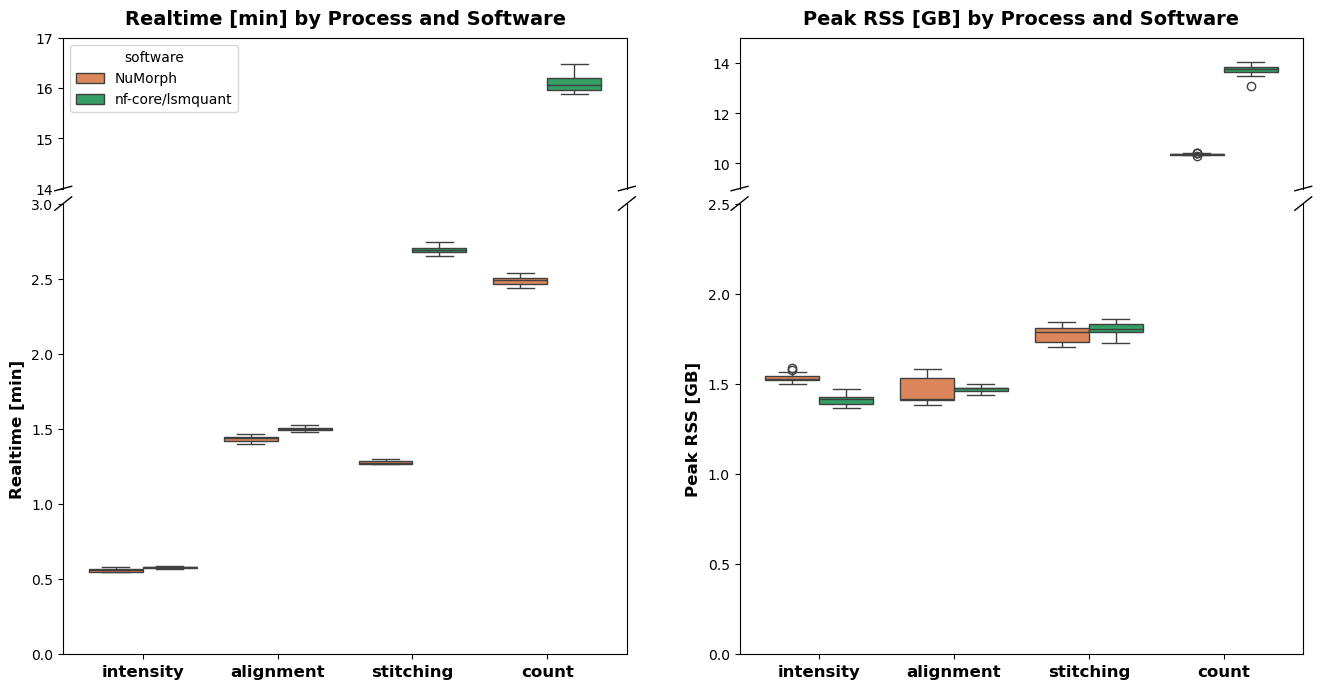

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(16, 8),
                          gridspec_kw={"height_ratios": [1, 3], "hspace": 0.05})

for col, (y_col, y_label, y_lims_top, y_lims_bot) in enumerate([
    ("realtime",  "Realtime [min]", (14, 17), (0, 3)),
    ("peak_rss",  "Peak RSS [GB]",      (9, 15),    (0, 2.5)),
]):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    # Plot on both axes
    sns.boxplot(data=benchmark_df, x='process', y=y_col, hue='software', ax=ax_top, legend=col==0, palette=palette)
    sns.boxplot(data=benchmark_df, x='process', y=y_col, hue='software', ax=ax_bot, legend=False, palette=palette)

    # Set y limits to zoom into each range
    ax_top.set_ylim(*y_lims_top)
    ax_bot.set_ylim(*y_lims_bot)

    # Hide the x-axis on top, y-axis label only on bottom
    ax_top.set_xlabel("")
    ax_top.set_xticklabels([])
    ax_top.set_ylabel("")
    ax_bot.set_ylabel(y_label, va="center", labelpad=10, fontsize=12, fontweight="bold")
    ax_bot.set_xlabel("")
    #ax_bot.set_xlabel("Process", labelpad=10, fontsize=12, fontweight="bold")
    ax_bot.set_xticklabels(benchmark_df['process'].unique(), fontsize=12, fontweight="bold")
    ax_top.set_title(f"{y_label.split(' (')[0]} by Process and Software", fontsize=14, pad=10, fontweight="bold")

    # Broken axis cosmetics — hide inner spines
    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(bottom=False)

    # Draw diagonal break marks
    d = 0.015
    kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, linewidth=1)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1-d, 1+d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# Move legend to top-left plot
axes[0, 0].legend(title="software", loc="upper left")

#plt.tight_layout()
plt.show()

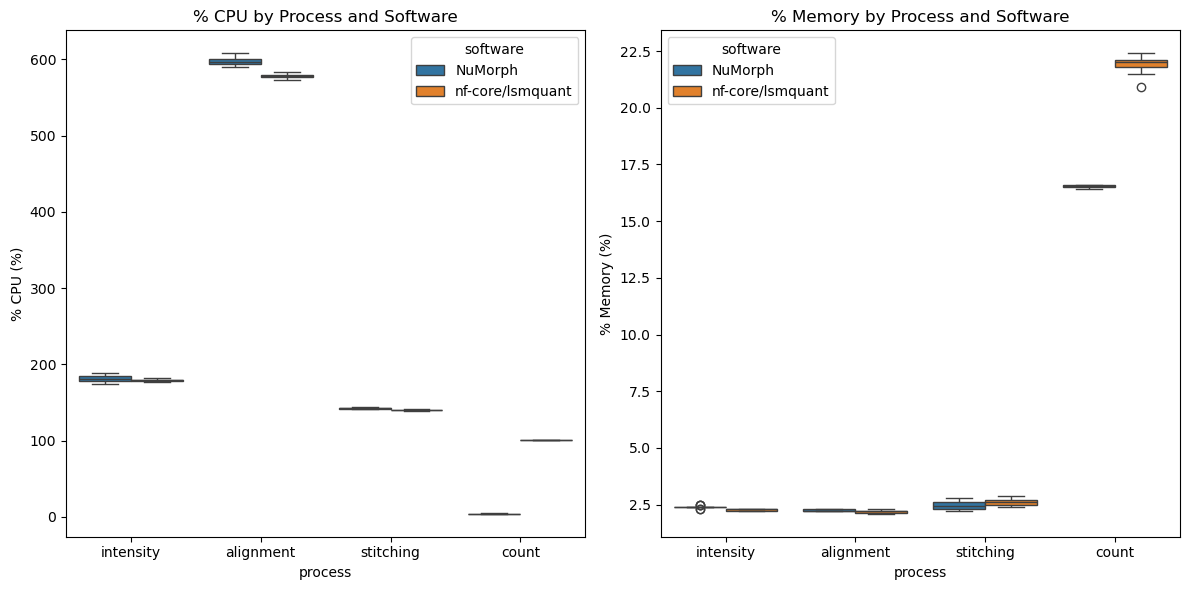

In [10]:
# plot the results as boxplots with seaborn, x axis is process, y axis is pcpu and pmem in two different plots, hue is software.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=combined_df, x='process', y='pcpu', hue='software')
#plt.yscale('log', base=2)
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('% CPU (%)')
plt.title('% CPU by Process and Software')
plt.subplot(1, 2, 2)
sns.boxplot(data=combined_df, x='process', y='pmem', hue='software')
#plt.yscale('log', base=2)
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('% Memory (%)')
plt.title('% Memory by Process and Software')
plt.tight_layout()
plt.show()

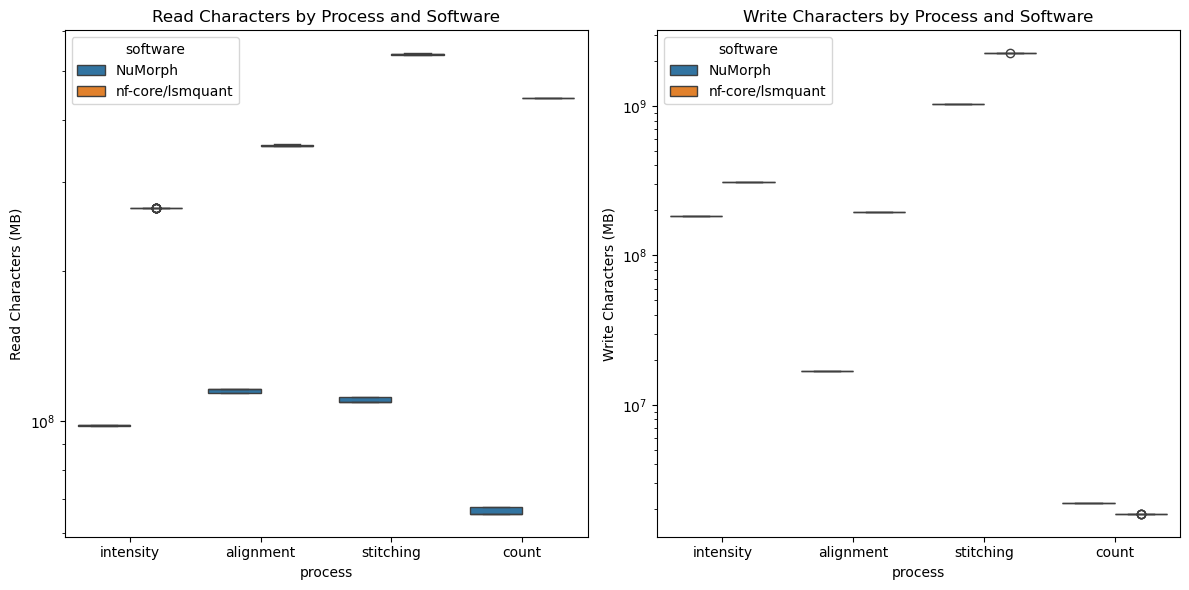

In [11]:
# plot the results as boxplots with seaborn, x axis is process, y axis is rchar and wchar in two different plots, hue is software.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=combined_df, x='process', y='rchar', hue='software')
plt.yscale('log')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Read Characters (MB)')
plt.title('Read Characters by Process and Software')
plt.subplot(1, 2, 2)
sns.boxplot(data=combined_df, x='process', y='wchar', hue='software')
plt.yscale('log')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Write Characters (MB)')
plt.title('Write Characters by Process and Software')
plt.tight_layout()
plt.show()

In [12]:
# plot only intensity, alignemnt and stitching since count is not comparable between the two software.
combined_df = combined_df[combined_df['process'].isin(['intensity', 'alignment', 'stitching'])]
combined_df = combined_df.assign(software=combined_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
combined_df = combined_df[combined_df['process'] == 'count']
combined_df = combined_df.assign(software=count_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))




NameError: name 'count_df' is not defined

In [13]:
palette = {
    "NuMorph": "#F18046",
    "nf-core/lsmquant": "#24B064"
}

NameError: name 'filtered_df' is not defined

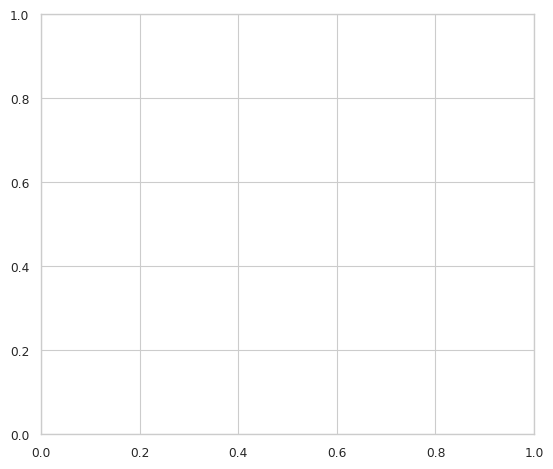

In [14]:
#sns.set_theme
sns.set_theme(style="whitegrid")
sns.set_context("paper")
plt.figure(figsize=(14, 12))
plt.subplot(2, 2, 1)
sns.boxplot(data=filtered_df, x='process', y='realtime', hue='software', palette=palette)
plt.ylabel('Realtime (seconds)')
plt.title('Realtime by Process and Software')
plt.subplot(2, 2, 2)
sns.boxplot(data=filtered_df, x='process', y='peak_rss', hue='software', palette=palette)
plt.ylabel('Peak RSS (GB)')
plt.title('Peak RSS by Process and Software')   
plt.subplot(2, 2, 3)
sns.boxplot(data=count_df, x='software', y='realtime', hue='software', palette=palette)
plt.ylabel('Realtime (seconds)')
plt.title('Realtime for Count Process by Software')
plt.subplot(2, 2, 4)
sns.boxplot(data=count_df, x='software', y='peak_rss', hue='software', palette=palette)
plt.ylabel('Peak RSS (GB)')
plt.title('Peak RSS for Count Process by Software') 
sns.despine()

plt.show()


In [15]:
stitch_df = combined_df[combined_df['process'] == 'stitching']

In [16]:
sum_stat_stitch = stitch_df.groupby('software').agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
sum_stat_stitch

Empty DataFrame
Columns: [(realtime, mean), (realtime, std), (peak_rss, mean), (peak_rss, std), (read_bytes, mean), (read_bytes, std), (write_bytes, mean), (write_bytes, std), (pcpu, mean), (pcpu, std), (pmem, mean), (pmem, std)]
Index: []

In [17]:
# get summary statistics for the count process only
# add a new row that shows the differences of means for each metric between the two software for the count process
summary_stat = count_df.groupby('software').agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
summary_stat.loc['difference'] = summary_stat.loc['nextflow'] - summary_stat.loc['matlab']
summary_stat

NameError: name 'count_df' is not defined

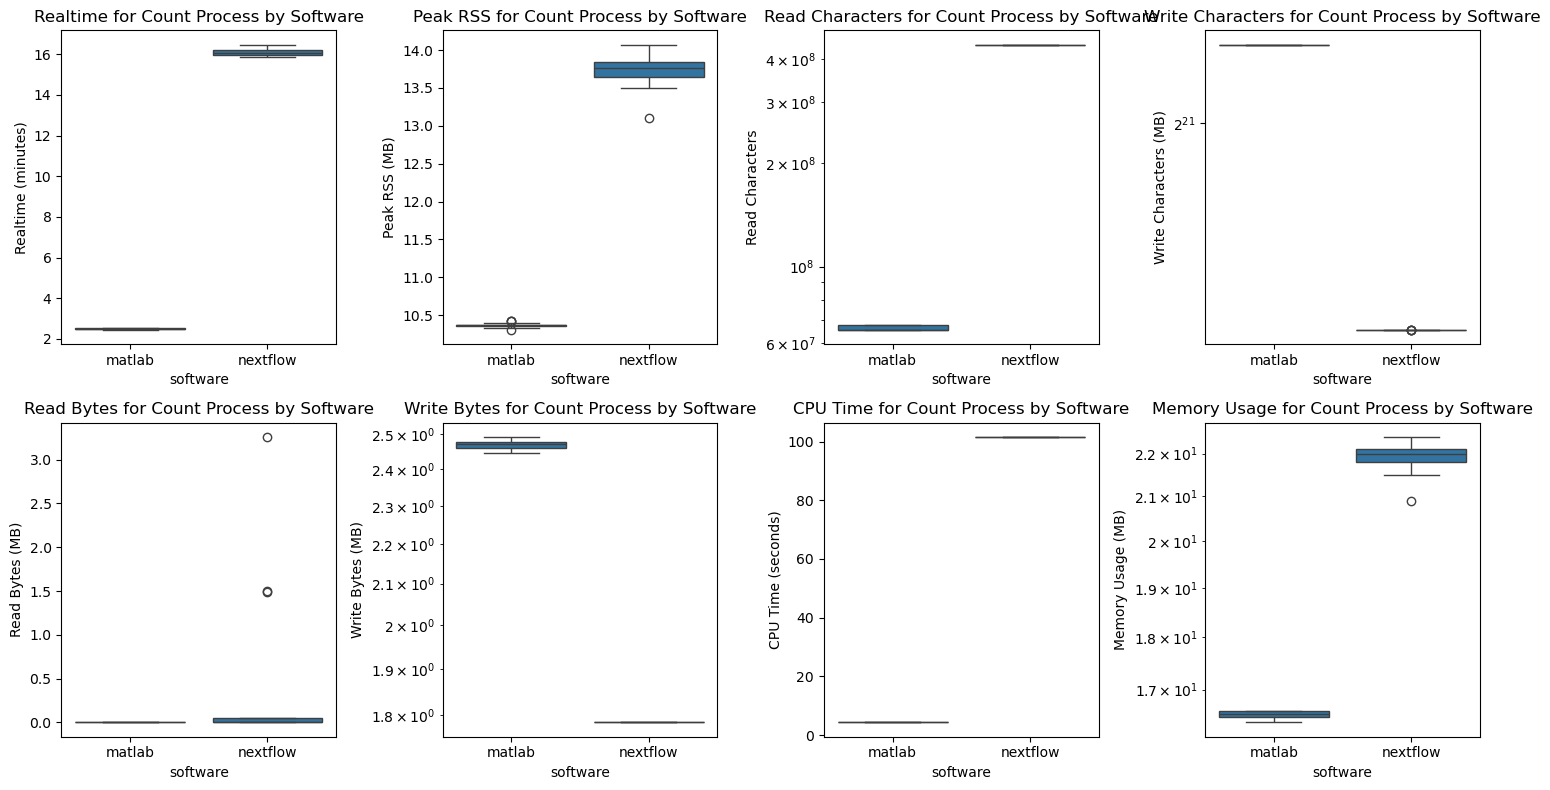

In [18]:
# compare only the count process between the two software. 
# how to the differnet valueas are for the count process between the two software.
plt.figure(figsize=(15, 8))
plt.subplot(2, 4, 1)
sns.boxplot(data=count_df, x='software', y='realtime')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Realtime (minutes)')
plt.title('Realtime for Count Process by Software')
plt.subplot(2, 4, 2)
sns.boxplot(data=count_df, x='software', y='peak_rss')
#plt.yscale('log', base=2)
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Peak RSS (MB)')
plt.title('Peak RSS for Count Process by Software')
plt.subplot(2, 4, 3)
sns.boxplot(data=count_df, x='software', y='rchar')
plt.yscale('log')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Read Characters')
plt.title('Read Characters for Count Process by Software')
plt.subplot(2, 4, 4)
sns.boxplot(data=count_df, x='software', y='wchar')
plt.yscale('log', base=2)
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Write Characters (MB)')
plt.title('Write Characters for Count Process by Software')
plt.subplot(2, 4, 5)
sns.boxplot(data=count_df, x='software', y='read_bytes')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Read Bytes (MB)')
plt.title('Read Bytes for Count Process by Software')
plt.subplot(2, 4, 6)
sns.boxplot(data=count_df, x='software', y='write_bytes')
plt.yscale('log', base=10)
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Write Bytes (MB)')
plt.title('Write Bytes for Count Process by Software')  
plt.subplot(2, 4, 7)
sns.boxplot(data=count_df, x='software', y='pcpu')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('CPU Time (seconds)')
plt.title('CPU Time for Count Process by Software')  
plt.subplot(2, 4, 8)
sns.boxplot(data=count_df, x='software', y='pmem')
plt.yscale('log')
#plt.gca().yaxis.set_major_locator(LogLocator(base=2.0, numticks=10))  # Adjust the number of ticks
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage for Count Process by Software')  

plt.tight_layout()
plt.show()

In [18]:
nextflow_scaling_data = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration': [21,0, 55, 73, 91,]}

nextflow_df_scaling = pd.DataFrame()

In [19]:
# scaling results 

NuMorph = pd.read_csv('scaling_summary.csv')
NuMorph.drop(columns=['total_wall_m', 'sum_process_m'], inplace=True)
# convert ms into minutes
NuMorph['total_wall_ms'] = NuMorph['total_wall_ms'] / 60000
NuMorph

,n_samples,total_wall_ms,sum_process_ms
0,1,6.013817,360794
1,2,11.850233,710946
2,3,17.704017,1062142
3,4,23.611050,1416527
4,5,29.538333,1772134
5,6,35.297950,2117669
6,7,41.415767,2484707
7,8,47.372383,2842080
8,9,53.524733,3211193
9,10,59.206500,3552063


In [20]:
matlab_process = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [3.08, 6.12, 9.07, 12.19, 15.19, 18.32, 21.30, 24.46, 27.85, 30.71]}
nextflow_scaling_data = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [4.75, 5.67, 7.57, 8.92, 10.92, 12.15, 14.23, 15.95, 17.80, 19.70]}

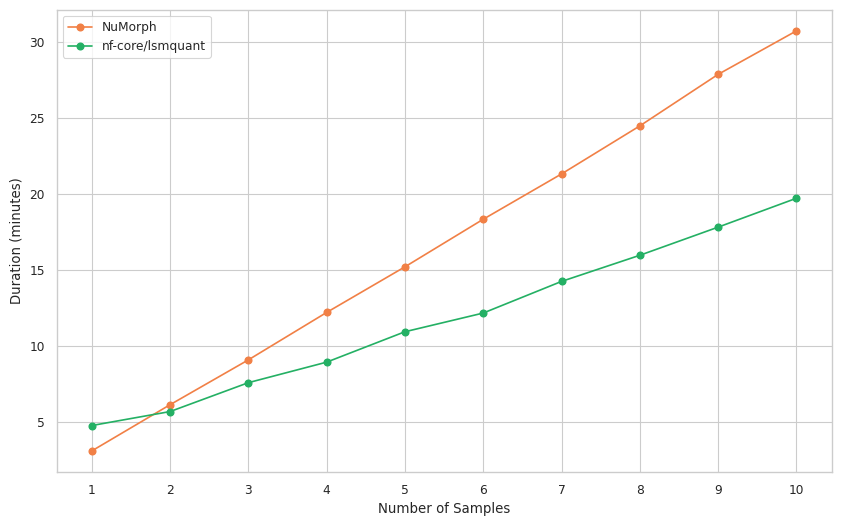

In [21]:
# plot the scaling results: x axis is n_samples and y axis is the duration in minutesfor numorph and nf-core/lsmquant
# show all x axis ticks
plt.figure(figsize=(10, 6))
plt.plot(matlab_process['n_samples'], matlab_process['duration [minutes]'], marker='o', label='NuMorph', color='#F18046')
plt.plot(nextflow_scaling_data['n_samples'], nextflow_scaling_data['duration [minutes]'], marker='o', label='nf-core/lsmquant', color='#24B064')
plt.xlabel('Number of Samples')
plt.xticks(matlab_process['n_samples'])  # Show all x-axis ticks
plt.ylabel('Duration (minutes)')
#plt.title('Scaling of Total Wall Time with Number of Samples')
plt.legend()
plt.show()